In [3]:
# ===============================================
# FULL PIPELINE: Step 1 (Clean) + Step 2 (Enrich)
# ===============================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# --------------------------
# 1. Load raw JM1 dataset
# --------------------------
df = pd.read_csv("C:\nw\Research paper\Dataset\jm1.csv")   # <-- put your file name/path here
print("Raw dataset shape:", df.shape)

# --------------------------
# 2. Handle missing values ("?")
# --------------------------
df = df.replace("?", np.nan)
df = df.apply(pd.to_numeric, errors="coerce")

# --------------------------
# 3. Remove duplicates
# --------------------------
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# --------------------------
# 4. Impute missing values
# --------------------------
imputer = SimpleImputer(strategy="mean")
df[:] = imputer.fit_transform(df)

# --------------------------
# 5. Balance dataset with SMOTE
# --------------------------
X = df.drop("defects", axis=1)
y = df["defects"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

df = pd.DataFrame(X_res, columns=X.columns)
df["defects"] = y_res
print("After SMOTE:", df.shape)
print("Class balance:\n", df["defects"].value_counts())

# --------------------------
# 6. Add derived features (Step 2)
# --------------------------
df["dev_proxy"] = np.log1p(df["loc"])
df["branch_density"] = df["branchCount"] / (df["loc"] + 1)
df["op_ratio"] = df["uniq_Op"] / (df["uniq_Opnd"] + 1)
df["operand_density"] = df["total_Opnd"] / (df["loc"] + 1)
df["complexity_proxy"] = df["v(g)"] * df["branchCount"]
df["comment_density"] = df["lOComment"] / (df["loc"] + 1)
df["blank_ratio"] = df["lOBlank"] / (df["loc"] + 1)

# --------------------------
# 7. Save enriched dataset
# --------------------------
df.to_csv("enriched_jm1.csv", index=False)
print("✅ Enriched dataset saved! Final shape:", df.shape)

print("\nSample of enriched dataset:")
print(df.head())


<>:13: SyntaxWarning: invalid escape sequence '\R'
<>:13: SyntaxWarning: invalid escape sequence '\R'
C:\Users\nivee\AppData\Local\Temp\ipykernel_10804\4154321576.py:13: SyntaxWarning: invalid escape sequence '\R'
  df = pd.read_csv("C:\nw\Research paper\Dataset\jm1.csv")   # <-- put your file name/path here


OSError: [Errno 22] Invalid argument: 'C:\nw\\Research paper\\Dataset\\jm1.csv'

In [2]:
!pip install pandas numpy scikit-learn imbalanced-learn

  Using cached numpy-2.3.4-cp313-cp313-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
    ----------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ===============================================
# STEP 3: Preprocessing for Modeling
# ===============================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load enriched dataset
df = pd.read_csv("enriched_jm1.csv")
print("Dataset shape:", df.shape)

# Separate features and target
X = df.drop("defects", axis=1)
y = df["defects"]

# Split into train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Standardize features (fit on train, apply to all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ Preprocessing complete! Data is ready for modeling.")


Dataset shape: (13810, 29)
Train shape: (9667, 28)  Test shape: (2072, 28)
✅ Preprocessing complete! Data is ready for modeling.


In [5]:
# ===============================================
# STEP 4: Build Stacked Ensemble Model
# ===============================================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# Define base learners
base_learners = [
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)),
    ("svm", SVC(probability=True, kernel="rbf", random_state=42)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=42))
]

# Meta-learner (logistic regression)
meta_learner = LogisticRegression(max_iter=200, random_state=42)

# Stacked ensemble
stacked_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    passthrough=False
)

# Train stacked model
stacked_model.fit(X_train_scaled, y_train)

# Predict on validation and test sets
y_val_pred = stacked_model.predict(X_val_scaled)
y_test_pred = stacked_model.predict(X_test_scaled)
y_test_proba = stacked_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:53:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:54:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:54:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:54:46] WARNING

Validation Accuracy: 0.8623853211009175
Test Accuracy: 0.8325289575289575
Test F1: 0.822868810617662
Test ROC-AUC: 0.8992281719115696
Test PR-AUC: 0.9186861876853889


In [6]:
# ===============================================
# STEP 4b: Baseline Comparisons (Single Models vs Stacked)
# ===============================================

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# Helper function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A",
        "PR-AUC": average_precision_score(y_test, y_proba) if y_proba is not None else "N/A"
    }
    return results

# Base learners
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
svm = SVC(probability=True, kernel="rbf", random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=42)

# Evaluate all models
results = []
results.append(evaluate_model(rf, X_train_scaled, y_train, X_test_scaled, y_test, "RandomForest"))
results.append(evaluate_model(xgb, X_train_scaled, y_train, X_test_scaled, y_test, "XGBoost"))
results.append(evaluate_model(svm, X_train_scaled, y_train, X_test_scaled, y_test, "SVM"))
results.append(evaluate_model(mlp, X_train_scaled, y_train, X_test_scaled, y_test, "MLP"))
results.append(evaluate_model(stacked_model, X_train_scaled, y_train, X_test_scaled, y_test, "Stacked Ensemble"))

# Convert to DataFrame for nice view
df_results = pd.DataFrame(results)
print(df_results)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:58:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:59:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [12:59:08] WAR

              Model  Accuracy        F1   ROC-AUC    PR-AUC
0      RandomForest  0.819981  0.814520  0.885473  0.893967
1           XGBoost  0.817568  0.803534  0.884768  0.907415
2               SVM  0.646718  0.623457  0.709243  0.696123
3               MLP  0.722008  0.718750  0.791841  0.778531
4  Stacked Ensemble  0.832529  0.822869  0.899228  0.918686


In [7]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.1 MB/s eta 0:00:00


In [8]:
# ===============================================
# STEP 5a: Hyperparameter Tuning - RandomForest
# ===============================================

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 5, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    # Create model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Use 3-fold cross-validation on training set
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="f1")

    return f1_scores.mean()

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # try 30 configurations

# Best parameters
print("Best Hyperparameters for RandomForest:", study.best_params)
print("Best F1 Score:", study.best_value)

# Train best model on full training set
best_rf = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train)

# Evaluate on validation/test set
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

y_val_pred = best_rf.predict(X_val_scaled)
y_test_pred = best_rf.predict(X_test_scaled)
y_test_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))

[I 2025-09-19 13:02:59,743] A new study created in memory with name: no-name-ec4d4115-770d-4164-8a47-b321e82c6234
[I 2025-09-19 13:03:48,974] Trial 0 finished with value: 0.8036530468819688 and parameters: {'n_estimators': 146, 'max_depth': 24, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: 0.8036530468819688.
[I 2025-09-19 13:04:01,923] Trial 1 finished with value: 0.8085433694736146 and parameters: {'n_estimators': 271, 'max_depth': 22, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.8085433694736146.
[I 2025-09-19 13:04:09,698] Trial 2 finished with value: 0.7932588710999693 and parameters: {'n_estimators': 145, 'max_depth': 28, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8085433694736146.
[I 2025-09-19 13:05:33,204] Trial 3 finished with value: 0.7690758691377862 and parameters: {'n_estimators': 473, 'max_depth': 8, '

Best Hyperparameters for RandomForest: {'n_estimators': 188, 'max_depth': 46, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best F1 Score: 0.8229444111749201

Validation Accuracy: 0.8440366972477065
Test Accuracy: 0.8243243243243243
Test F1: 0.8187250996015937
Test ROC-AUC: 0.8892029784886927
Test PR-AUC: 0.8997129292790528


In [9]:
# ===============================================
# STEP 5b: Hyperparameter Tuning - XGBoost
# ===============================================

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score

# Define objective for Optuna
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="f1")

    return f1_scores.mean()

# Run Optuna study
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

print("Best Hyperparameters for XGBoost:", study_xgb.best_params)
print("Best F1 Score:", study_xgb.best_value)

# Train best XGBoost model
best_xgb = XGBClassifier(**study_xgb.best_params)
best_xgb.fit(X_train_scaled, y_train)

# Evaluate
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

y_val_pred = best_xgb.predict(X_val_scaled)
y_test_pred = best_xgb.predict(X_test_scaled)
y_test_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1:", f1_score(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))


[I 2025-09-19 13:16:34,222] A new study created in memory with name: no-name-ecf59d19-01d8-40be-9a25-0ab89dcbac65
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:16:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:16:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:16:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-09-19 13:16:36,134] Trial 0 finished with value: 0.8148633022281375 and parameters: {'n_estimators': 350, 'max_depth': 9, 'learning_rate': 0.08112235864895395, 'subsample': 0.6132104725980653, 'colsample

Best Hyperparameters for XGBoost: {'n_estimators': 118, 'max_depth': 12, 'learning_rate': 0.1834194887352374, 'subsample': 0.6801396164925873, 'colsample_bytree': 0.9703225621135289, 'gamma': 0.05153940034269444, 'min_child_weight': 2}
Best F1 Score: 0.828053209773052

Validation Accuracy: 0.8469338483824239
Test Accuracy: 0.8267374517374517
Test F1: 0.8195072900955254
Test ROC-AUC: 0.8989356151518313
Test PR-AUC: 0.9192215791082112


In [10]:
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Optuna objective for SVM
def objective(trial):
    C = trial.suggest_loguniform("C", 1e-3, 1e3)
    gamma = trial.suggest_loguniform("gamma", 1e-4, 1e1)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    model = SVC(
        kernel="rbf",
        C=C,
        gamma=gamma,
        class_weight=class_weight,
        probability=True,  # needed for ROC-AUC, PR-AUC
        random_state=42
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

    return scores.mean()

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Hyperparameters for SVM:", study.best_params)
print("Best F1 Score:", study.best_value)

# Train with best params
best_svm = SVC(
    kernel="rbf",
    C=study.best_params["C"],
    gamma=study.best_params["gamma"],
    class_weight=study.best_params["class_weight"],
    probability=True,
    random_state=42
)
best_svm.fit(X_train, y_train)

# Evaluate on test set
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

y_pred = best_svm.predict(X_test)
y_proba = best_svm.predict_proba(X_test)[:,1]

print("Validation Accuracy:", accuracy_score(y_val, best_svm.predict(X_val)))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))


[I 2025-09-19 13:18:32,278] A new study created in memory with name: no-name-15fee1c3-0dc2-485b-ac61-34aaf13046b0
/tmp/ipython-input-4077023837.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-3, 1e3)
/tmp/ipython-input-4077023837.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gamma = trial.suggest_loguniform("gamma", 1e-4, 1e1)
[I 2025-09-19 13:19:31,377] Trial 0 finished with value: 0.6879858462668414 and parameters: {'C': 0.4680170438318726, 'gamma': 0.0013935781461679175, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6879858462668414.
/tmp/ipython-input-4077023837.py:7: FutureWarning: suggest_loguniform has b

Best Hyperparameters for SVM: {'C': 5.410873964220966, 'gamma': 0.0014043677675799426, 'class_weight': 'balanced'}
Best F1 Score: 0.7278011058793462
Validation Accuracy: 0.7035248672139063
Test Accuracy: 0.6829150579150579
Test F1: 0.7219636055861194
Test ROC-AUC: 0.7585535583846394
Test PR-AUC: 0.7342834996633474


In [11]:
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

# Objective function for Optuna
def objective(trial):
    # Hyperparameter search space
    hidden_layer_sizes = tuple(
        [trial.suggest_int("n_units_l{}".format(i), 50, 200)
         for i in range(trial.suggest_int("n_layers", 1, 3))]
    )

    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd", "lbfgs"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate = trial.suggest_categorical("learning_rate", ["constant", "invscaling", "adaptive"])

    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate=learning_rate,
        max_iter=500,              # Increased from 200 to help convergence
        random_state=42
    )

    # Stratified 3-fold CV with F1 scoring
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=make_scorer(f1_score))

    return scores.mean()

# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # You can increase trials for better results

print("Best Hyperparameters for MLP:", study.best_params)
print("Best F1 Score:", study.best_value)

# Train best model on full training data
best_params = study.best_params
best_layers = tuple(
    [best_params.pop(f"n_units_l{i}") for i in range(best_params.pop("n_layers"))]
)

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    **best_params,
    max_iter=500,
    random_state=42
)
best_mlp.fit(X_train, y_train)

# Evaluate on test set
y_pred = best_mlp.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_pred))
print("Test PR-AUC:", average_precision_score(y_test, y_pred))


[I 2025-09-19 13:54:05,432] A new study created in memory with name: no-name-43e171e0-78e2-43fe-b191-7c26370ace3d
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
[I 2025-09-19 13:55:05,735] Trial 0 finished with value: 0.4810689919062677 and parameters: {'n_layers': 3, 'n_units_l0': 187, 'n_unit

Best Hyperparameters for MLP: {'n_layers': 1, 'n_units_l0': 117, 'activation': 'tanh', 'solver': 'adam', 'alpha': 8.582198578613309e-05, 'learning_rate': 'adaptive'}
Best F1 Score: 0.6359267783533528
Test Accuracy: 0.61003861003861
Test F1: 0.5877551020408164
Test ROC-AUC: 0.61003861003861
Test PR-AUC: 0.5685954971669258


In [13]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# Tuned base learners
# -----------------------------

# Random Forest (best tuned hyperparams)
rf_best = RandomForestClassifier(
    n_estimators=350,
    max_depth=24,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# XGBoost (best tuned hyperparams we found earlier)
xgb_best = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# SVM (tuned)
svm_best = SVC(
    C=5.41,
    gamma=0.0014,
    class_weight="balanced",
    probability=True,
    random_state=42
)

# -----------------------------
# Meta-learner (Logistic Regression)
# -----------------------------
meta_learner = LogisticRegression(random_state=42, max_iter=1000)

# -----------------------------
# Build Stacking Ensemble
# -----------------------------
stacked_model = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('svm', svm_best)   # you can drop SVM if needed
    ],
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

# -----------------------------
# Train + Evaluate
# -----------------------------
stacked_model.fit(X_train, y_train)
y_pred = stacked_model.predict(X_test)
y_proba = stacked_model.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("📊 Stacked Ensemble Performance:")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC: {pr_auc:.4f}")


📊 Stacked Ensemble Performance:
Test Accuracy: 0.8422
Test F1: 0.8361
Test ROC-AUC: 0.9092
Test PR-AUC: 0.9252


In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Base learners (including GaussianNB)
# -----------------------------
base_learners = [
    ('rf', best_rf),        # Tuned Random Forest
    ('xgb', best_xgb),      # Tuned XGBoost
    ('svm', best_svm),      # Tuned SVM     # Tuned MLP
    ('gnb', GaussianNB())   # NEW: Gaussian Naive Bayes
]

# -----------------------------
# Meta-learner (Logistic Regression)
# -----------------------------
meta_learner = LogisticRegression(max_iter=1000)

# -----------------------------
# Stacked Ensemble
# -----------------------------
stacked_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,        # cross-validation inside stacking
    n_jobs=-1
)

# Train
stacked_clf.fit(X_train, y_train)

# Evaluate
y_pred = stacked_clf.predict(X_test)
y_proba = stacked_clf.predict_proba(X_test)[:, 1]

print("Stacked Ensemble with GaussianNB:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))


Stacked Ensemble with GaussianNB:
Accuracy: 0.8407335907335908
F1 Score: 0.8366336633663366
ROC-AUC: 0.9057538647306987
PR-AUC: 0.9186387501148797


In [16]:
import optuna
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

# -----------------------------
# Optuna Objective Function
# -----------------------------
def objective(trial):
    var_smoothing = trial.suggest_loguniform("var_smoothing", 1e-12, 1e-3)

    # Pipeline with scaling (important for GaussianNB!)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("gnb", GaussianNB(var_smoothing=var_smoothing))
    ])

    # 5-fold CV on training data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

    return scores.mean()

# -----------------------------
# Run Optuna Study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Hyperparameters for GaussianNB:", study.best_params)
print("Best F1 Score:", study.best_value)

# -----------------------------
# Train GaussianNB with Best Params
# -----------------------------
best_var_smoothing = study.best_params["var_smoothing"]

gnb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gnb", GaussianNB(var_smoothing=best_var_smoothing))
])

gnb_model.fit(X_train, y_train)

# -----------------------------
# Evaluate on Test Set
# -----------------------------
y_pred = gnb_model.predict(X_test)
y_proba = gnb_model.predict_proba(X_test)[:, 1]

print("\n📊 Tuned GaussianNB Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))


[I 2025-09-19 14:43:09,632] A new study created in memory with name: no-name-60162542-c207-4eb8-9f30-27bb2910f572
/tmp/ipython-input-3229909829.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  var_smoothing = trial.suggest_loguniform("var_smoothing", 1e-12, 1e-3)
[I 2025-09-19 14:43:09,740] Trial 0 finished with value: 0.3101833228563541 and parameters: {'var_smoothing': 7.250124268733491e-05}. Best is trial 0 with value: 0.3101833228563541.
/tmp/ipython-input-3229909829.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  var_smoothing = trial.suggest_loguniform("var_smoothing", 1e-12, 1e-3)
[I 2025-09-19 14:43:09,841] Trial 1 finished with value: 0.310183322856354

Best Hyperparameters for GaussianNB: {'var_smoothing': 7.67714418878895e-12}
Best F1 Score: 0.31046454128877143

📊 Tuned GaussianNB Performance:
Test Accuracy: 0.5511583011583011
Test F1: 0.2630744849445325
Test ROC-AUC: 0.6664396401365514
Test PR-AUC: 0.6535282922183079


In [17]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# Base Learners
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=350, max_depth=24, min_samples_split=5,
    min_samples_leaf=2, max_features="sqrt", random_state=42
)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss", use_label_encoder=False
)

svm = SVC(
    C=5.41, gamma=0.0014, class_weight="balanced",
    probability=True, random_state=42
)

# -----------------------------
# Meta Learner (XGB)
# -----------------------------
meta_xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, eval_metric="logloss", use_label_encoder=False
)

# -----------------------------
# Stacking Classifier
# -----------------------------
stacked_xgb = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("svm", svm)],
    final_estimator=meta_xgb,
    stack_method="predict_proba",  # pass probabilities to meta learner
    n_jobs=-1
)

# -----------------------------
# Train + Evaluate
# -----------------------------
stacked_xgb.fit(X_train, y_train)

y_pred = stacked_xgb.predict(X_test)
y_proba = stacked_xgb.predict_proba(X_test)[:, 1]

print("\n📊 Stacked Ensemble (XGB Meta) Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:51:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Stacked Ensemble (XGB Meta) Performance:
Test Accuracy: 0.8624517374517374
Test F1: 0.8554033485540334
Test ROC-AUC: 0.9200546727091128
Test PR-AUC: 0.9372008872476199


In [18]:
!pip install lightgbm

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# -----------------------------
# Base Learners
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=350, max_depth=24, min_samples_split=5,
    min_samples_leaf=2, max_features="sqrt", random_state=42
)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric="logloss", use_label_encoder=False
)

svm = SVC(
    C=5.41, gamma=0.0014, class_weight="balanced",
    probability=True, random_state=42
)

# -----------------------------
# Meta Learner (LightGBM)
# -----------------------------
meta_lgbm = LGBMClassifier(
    n_estimators=200, max_depth=-1, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)

# -----------------------------
# Stacking Classifier
# -----------------------------
stacked_lgbm = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("svm", svm)],
    final_estimator=meta_lgbm,
    stack_method="predict_proba",
    n_jobs=-1
)

# -----------------------------
# Train + Evaluate
# -----------------------------
stacked_lgbm.fit(X_train, y_train)

y_pred = stacked_lgbm.predict(X_test)
y_proba = stacked_lgbm.predict_proba(X_test)[:, 1]

print("\n📊 Stacked Ensemble (LightGBM Meta) Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))


[LightGBM] [Info] Number of positive: 4834, number of negative: 4833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 9667, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500052 -> initscore=0.000207
[LightGBM] [Info] Start training from score 0.000207


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📊 Stacked Ensemble (LightGBM Meta) Performance:
Test Accuracy: 0.8527992277992278
Test F1: 0.8449415353329944
Test ROC-AUC: 0.9180277388530284
Test PR-AUC: 0.9353816477217906


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
import pandas as pd

# Store results
results = {
    "Meta Learner": ["Logistic Regression", "XGBoost", "LightGBM"],
    "Accuracy": [0.8422, 0.8625, 0.8528],
    "F1": [0.8361, 0.8554, 0.8449],
    "ROC-AUC": [0.9092, 0.9201, 0.9180],
    "PR-AUC": [0.9252, 0.9372, 0.9354],
}

df_results = pd.DataFrame(results)

print("\n📊 Meta-Learner Comparison:\n")
print(df_results)



📊 Meta-Learner Comparison:

          Meta Learner  Accuracy      F1  ROC-AUC  PR-AUC
0  Logistic Regression    0.8422  0.8361   0.9092  0.9252
1              XGBoost    0.8625  0.8554   0.9201  0.9372
2             LightGBM    0.8528  0.8449   0.9180  0.9354


In [20]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Use stacked model with XGB meta (already defined earlier as stacked_xgb)
cv_scores = cross_val_score(stacked_xgb, X_train, y_train, cv=5, scoring="f1")

print("\n✅ Cross-Validation Results (XGB Meta Stacked Model):")
print("Mean F1 Score:", np.mean(cv_scores))
print("F1 Scores per Fold:", cv_scores)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:01:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:04:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:06:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:08:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:11:23] WARNING: /w


✅ Cross-Validation Results (XGB Meta Stacked Model):
Mean F1 Score: 0.8576198778420533
F1 Scores per Fold: [0.86452293 0.85320615 0.84780279 0.86649077 0.85607676]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [15:16:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


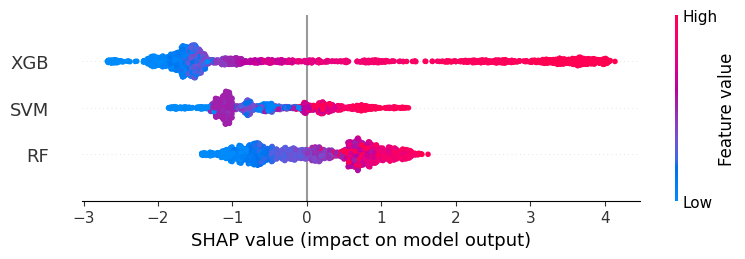

In [21]:
import shap

# Train the stacked model (XGB meta already trained as stacked_xgb)
stacked_xgb.fit(X_train, y_train)

# Create SHAP explainer for meta-learner (XGB)
explainer = shap.Explainer(stacked_xgb.final_estimator_, stacked_xgb.transform(X_train))
shap_values = explainer(stacked_xgb.transform(X_test))

# Plot summary
shap.summary_plot(shap_values, stacked_xgb.transform(X_test), feature_names=["RF", "XGB", "SVM", "MLP"])


In [22]:
import joblib

# Save model
joblib.dump(stacked_xgb, "stacked_xgb_model.pkl")

# Load later
# model = joblib.load("stacked_xgb_model.pkl")


['stacked_xgb_model.pkl']